<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 40px;
font-family: 'Segoe UI', sans-serif;
font-weight: 400;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<b style="color: #00cfff;">⚡</b>
<span style="color: #ffffff;">Exercícios Aprendizado Profundo - QUESTÃO 4</span>
</div>

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;"> 4)
<ul>

<li>(a) Implemente e treine um autoencoder utilizando o dataset Fashion-MNIST, disponível em:
https://www.kaggle.com/datasets/zalando-research/fashionmnist. O objetivo deste exercício é
compreender como esse tipo de rede neural é capaz de aprender representações comprimidas
de dados e realizar reconstruções a partir dessas representações. O autoencoder pode ser
construído utilizando apenas camadas densas (fully connected) ou, alternativamente, camadas
convolucionais e deconvolucionais.
Após o treinamento, selecione 10 imagens do conjunto de teste e utilize o modelo treinado para
gerar as reconstruções correspondentes. Apresente os resultados visualmente, exibindo lado a
lado as imagens originais e suas respectivas reconstruções, de modo que seja possível avaliar
qualitativamente o desempenho do autoencoder. Apresente também a curva do erro médio ao
longo do treinamento.


<li>(b) Complete o exercício da questão 3(a) adicionando ruído aleatório às imagens de entrada,
com o objetivo de treinar um denoising autoencoder. Após o treinamento, utilize as 10 imagens
selecionadas na questão anterior (com o ruído aplicado) e apresente os resultados
visualmente, exibindo lado a lado as imagens originais e suas respectivas reconstruções. Avalie
qualitativamente o desempenho do modelo em remover o ruído e preservar as características
das imagens originais.
</ul>
</span>
</div>

In [60]:
import numpy as np
import pandas as pd

file  = "Fashion_mnist/fashion-mnist_test.csv"
test_set = pd.read_csv(file)

# Separa rótulos e pixels
y_test = test_set["label"].values
X_test = test_set.drop("label", axis=1).values

X_test = X_test.astype("float32") / 255.0

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (10000, 784)
y_test: (10000,)


In [61]:
file  = "Fashion_mnist/fashion-mnist_train.csv"
train_set = pd.read_csv(file)

# Separa rótulos e pixels
y_train = train_set["label"].values
X_train = train_set.drop("label", axis=1).values

X_train = X_train.astype("float32") / 255.0

print("X_train", X_train.shape)
print("y_train:", y_train.shape)

X_train (60000, 784)
y_train: (60000,)


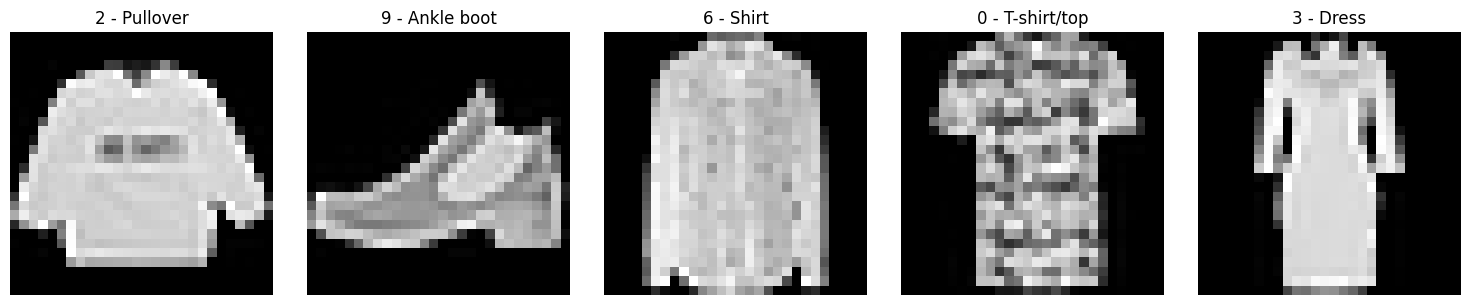

In [62]:
import matplotlib.pyplot as plt

# Lista de classes do Fashion-MNIST
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Plota 5 imagens do conjunto de treino
num_imagens = 5
fig, axes = plt.subplots(1, num_imagens, figsize=(15, 3))

for i in range(num_imagens):
    imagem = train_set.iloc[i, 1:].values.reshape(28, 28)
    label = int(train_set.iloc[i, 0])

    axes[i].imshow(imagem, cmap="gray")
    axes[i].set_title(f"{label} - {classes[label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">AUTOENCODER Fully Connected</span>
</div>

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

In [64]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(28*28,)))
model.add(Dense(784, activation='sigmoid'))

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]


model.compile(
    optimizer='adam',
    loss='mean_squared_error',   
    metrics=METRICS
)

model.summary()

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,448 (1.54 MB)

 Trainable params: 402,448 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = model.fit(X_train, X_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=2)


Epoch 1/10
375/375 - 3s - 8ms/step - accuracy: 0.0146 - loss: 0.0315 - precision: 0.9761 - recall: 0.6279 - val_accuracy: 0.0228 - val_loss: 0.0156 - val_precision: 0.9955 - val_recall: 0.6432
Epoch 2/10
375/375 - 2s - 5ms/step - accuracy: 0.0295 - loss: 0.0121 - precision: 0.9976 - recall: 0.6150 - val_accuracy: 0.0342 - val_loss: 0.0110 - val_precision: 0.9976 - val_recall: 0.6571
Epoch 3/10
375/375 - 2s - 6ms/step - accuracy: 0.0399 - loss: 0.0090 - precision: 0.9988 - recall: 0.6140 - val_accuracy: 0.0456 - val_loss: 0.0084 - val_precision: 0.9988 - val_recall: 0.6362
Epoch 4/10
375/375 - 2s - 5ms/step - accuracy: 0.0496 - loss: 0.0075 - precision: 0.9992 - recall: 0.6157 - val_accuracy: 0.0519 - val_loss: 0.0071 - val_precision: 0.9993 - val_recall: 0.6313
Epoch 5/10
375/375 - 2s - 5ms/step - accuracy: 0.0573 - loss: 0.0065 - precision: 0.9995 - recall: 0.6174 - val_accuracy: 0.0614 - val_loss: 0.0063 - val_precision: 0.9996 - val_recall: 0.6103
Epoch 6/10
375/375 - 2s - 5ms/step 

In [66]:
x_pred = model.predict(X_test)

bin_acc = tf.keras.metrics.BinaryAccuracy(threshold=0.5)
bin_acc.update_state(X_test, x_pred)
acc_recon = float(bin_acc.result().numpy())

mse_recon = float(np.mean((X_test - x_pred) ** 2))

print(f"Acurácia de reconstrução: {acc_recon:.4f}")
print(f"MSE de reconstrução: {mse_recon:.6f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Acurácia de reconstrução: 0.5107
MSE de reconstrução: 0.004296


<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Reconstruções</span>
</div>

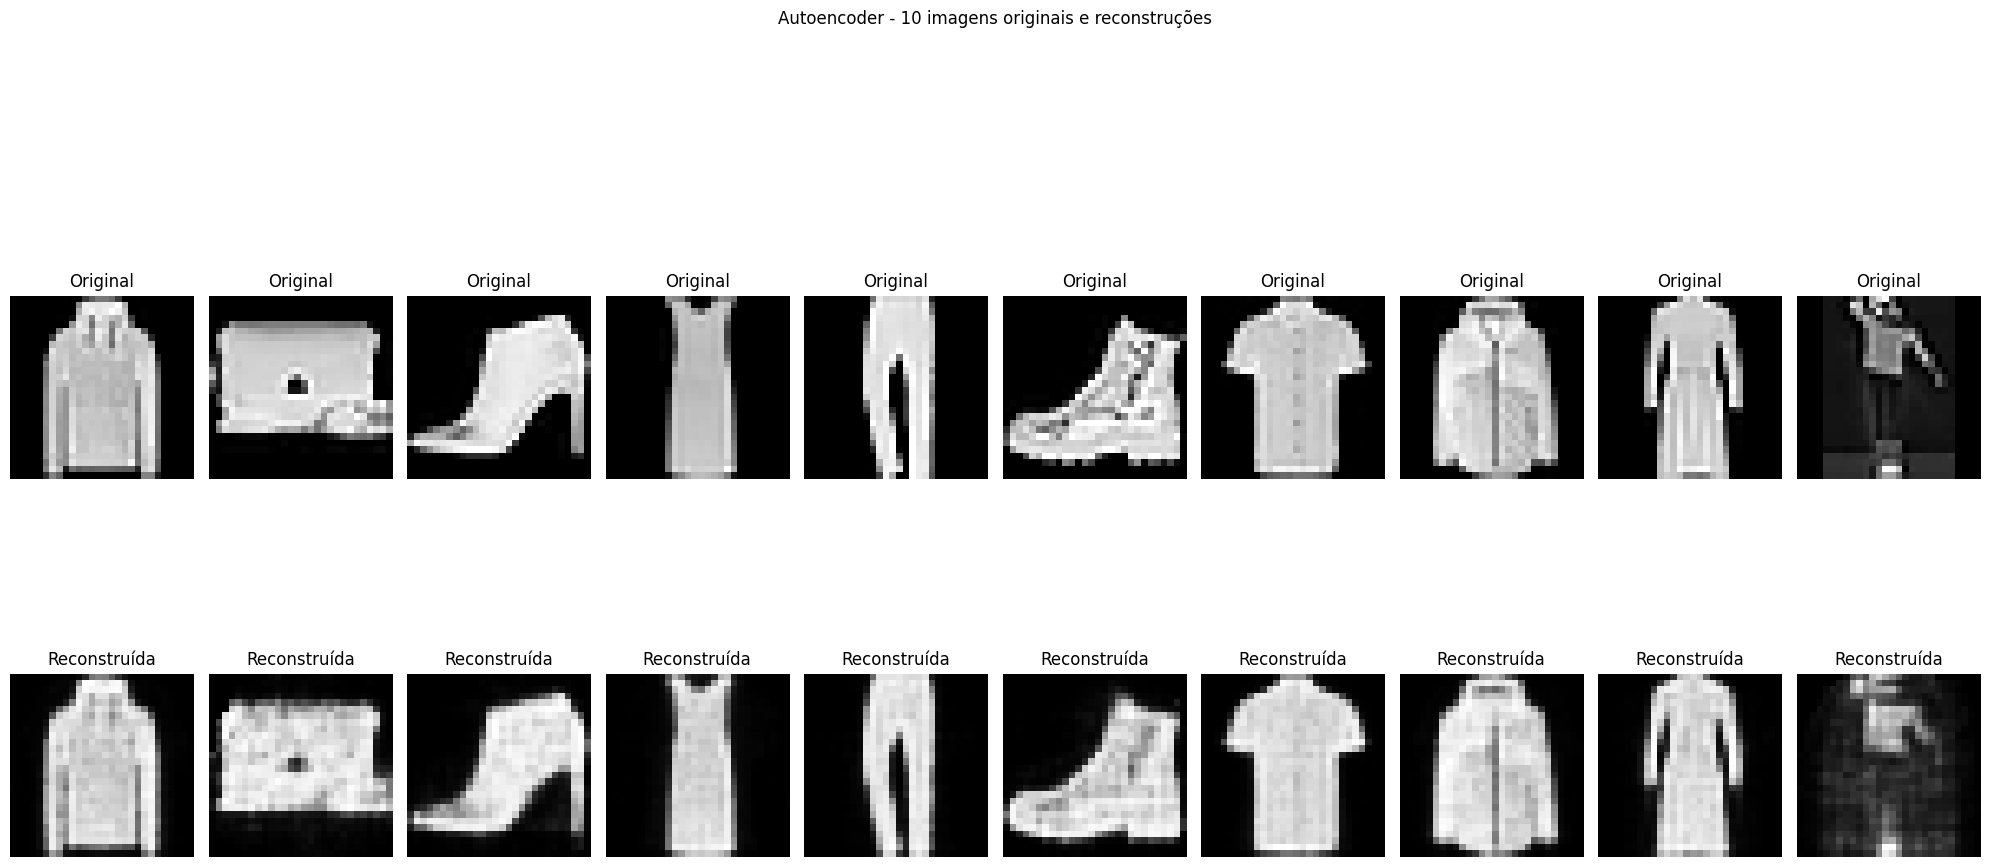

In [67]:
# 10 imagens de teste: original vs reconstruída
n = 10
idx = np.random.choice(len(X_test), n, replace=False)

originais = X_test[idx].reshape(-1, 28, 28)
reconstruidas = x_pred[idx].reshape(-1, 28, 28)

plt.figure(figsize=(20, 10))
for i in range(n):
    # Linha de cima: original
    ax = plt.subplot(2, 10, i + 1)
    ax.imshow(originais[i], cmap="gray")
    ax.set_title("Original")
    ax.axis("off")

    # Linha de baixo: reconstruída
    ax = plt.subplot(2, n, i + 1 + n)
    ax.imshow(reconstruidas[i], cmap="gray")
    ax.set_title("Reconstruída")
    ax.axis("off")

plt.suptitle("Autoencoder - 10 imagens originais e reconstruções", y=1.05)
plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">DENOISING AUTOENCODER (Questão 4b)</span>
</div>

In [68]:
# Reprodutibilidade
np.random.seed(42)

# Mantém as mesmas 10 imagens da questão anterior, se já existirem
try:
    selected_idx = idx
except NameError:
    selected_idx = np.random.choice(len(X_test), 10, replace=False)

# Adiciona ruído gaussiano nas entradas
noise_factor = 0.35
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# Mantém pixels no intervalo [0, 1]
X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0).astype("float32")
X_test_noisy = np.clip(X_test_noisy, 0.0, 1.0).astype("float32")

print("X_train_noisy:", X_train_noisy.shape)
print("X_test_noisy:", X_test_noisy.shape)
print("selected_idx:", selected_idx)

X_train_noisy: (60000, 784)
X_test_noisy: (10000, 784)
selected_idx: [3017 7877 8975 2338  760 5809 4337 5945 6396 4938]


In [ ]:
# Modelo denoising autoencoder (fully connected)
model_denoise = Sequential([
    tf.keras.layers.Input(shape=(28 * 28,)),
    Dense(256, activation="relu"),
    Dense(784, activation="sigmoid")
])

model_denoise.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

history_denoise = model_denoise.fit(
    X_train_noisy, X_train,  # entrada ruidosa -> alvo limpo
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

# Curva do erro médio no treinamento denoising
plt.figure(figsize=(8, 4))
plt.plot(history_denoise.history["loss"], label="Treino (MSE)")
plt.plot(history_denoise.history["val_loss"], label="Validação (MSE)")
plt.title("Denoising Autoencoder - Curva do erro médio")
plt.xlabel("Época")
plt.ylabel("Erro médio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1/10
375/375 - 3s - 7ms/step - loss: 0.0361 - val_loss: 0.0222
Epoch 2/10
375/375 - 2s - 6ms/step - loss: 0.0193 - val_loss: 0.0177
Epoch 3/10
375/375 - 2s - 5ms/step - loss: 0.0162 - val_loss: 0.0155
Epoch 4/10
375/375 - 2s - 5ms/step - loss: 0.0147 - val_loss: 0.0144
Epoch 5/10
375/375 - 2s - 5ms/step - loss: 0.0137 - val_loss: 0.0137
Epoch 6/10
375/375 - 2s - 6ms/step - loss: 0.0132 - val_loss: 0.0133
Epoch 7/10


MSE entrada ruidosa vs original: 0.068242
MSE reconstruída vs original:   0.012339
O modelo reduziu o ruído e aproximou as imagens do original.


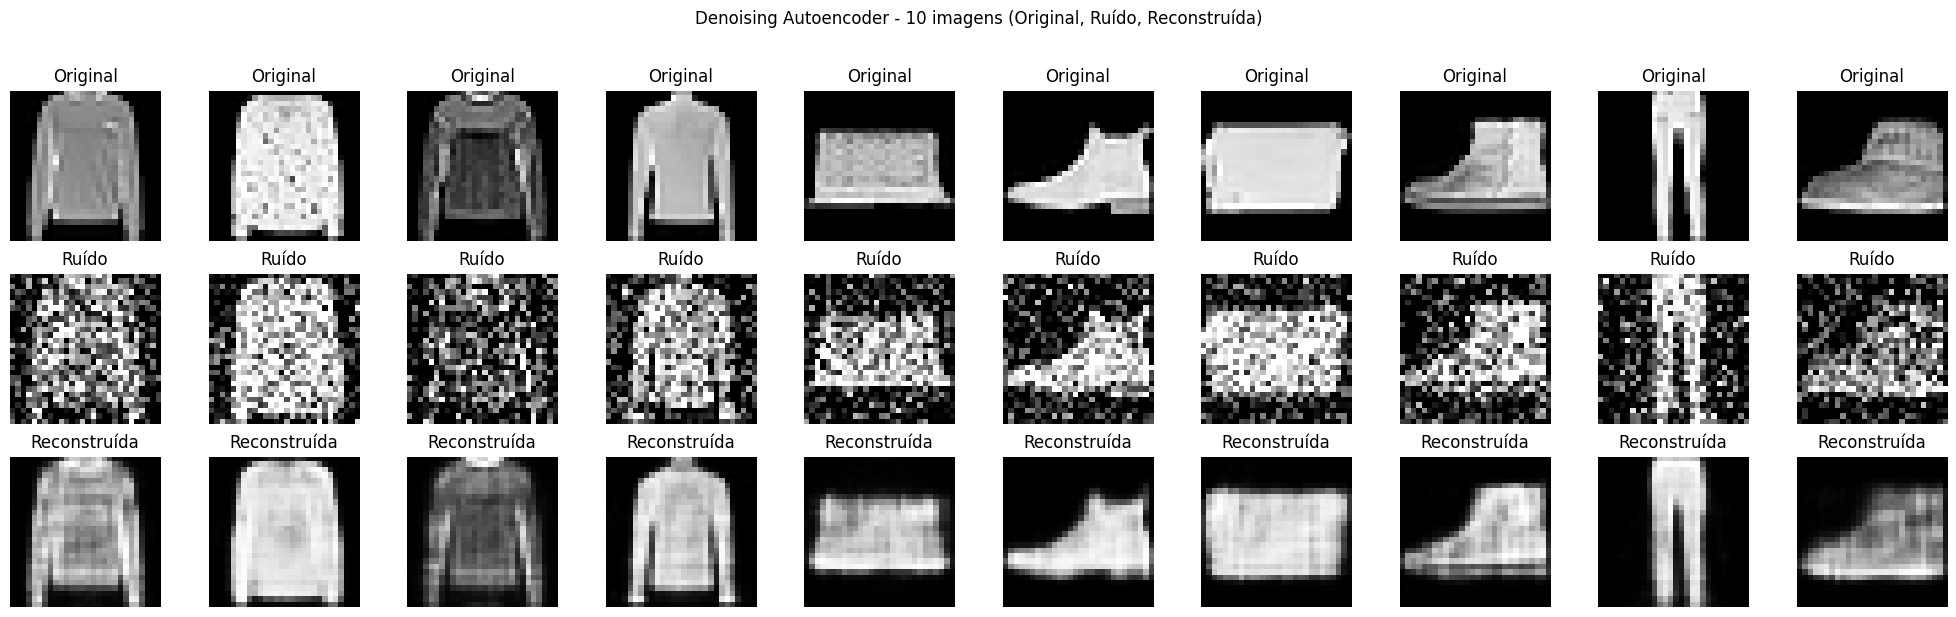

In [ ]:
# Reconstruções no conjunto de teste com ruído
x_test_denoised = model_denoise.predict(X_test_noisy, verbose=0)

# Métrica quantitativa (apoio à avaliação qualitativa)
mse_noisy = float(np.mean((X_test_noisy - X_test) ** 2))
mse_denoised = float(np.mean((x_test_denoised - X_test) ** 2))

print(f"MSE entrada com ruído vs original: {mse_noisy:.6f}")
print(f"MSE reconstruída vs original:   {mse_denoised:.6f}")

if mse_denoised < mse_noisy:
    print("O modelo reduziu o ruído e aproximou as imagens do original.")
else:
    print("O modelo ainda não superou a entrada ruidosa; ajuste epochs/arquitetura/ruído.")

# Mostra as mesmas 10 imagens: Original | Com ruído | Reconstruída
originais_10 = X_test[selected_idx].reshape(-1, 28, 28)
ruidosas_10 = X_test_noisy[selected_idx].reshape(-1, 28, 28)
recon_10 = x_test_denoised[selected_idx].reshape(-1, 28, 28)

n = len(selected_idx)
plt.figure(figsize=(2 * n, 6))

for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    ax.imshow(originais_10[i], cmap="gray")
    ax.set_title("Original")
    ax.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    ax.imshow(ruidosas_10[i], cmap="gray")
    ax.set_title("Ruído")
    ax.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    ax.imshow(recon_10[i], cmap="gray")
    ax.set_title("Reconstruída")
    ax.axis("off")

plt.suptitle("Denoising Autoencoder - 10 imagens (Original, Ruído, Reconstruída)", y=1.02)
plt.tight_layout()
plt.show()

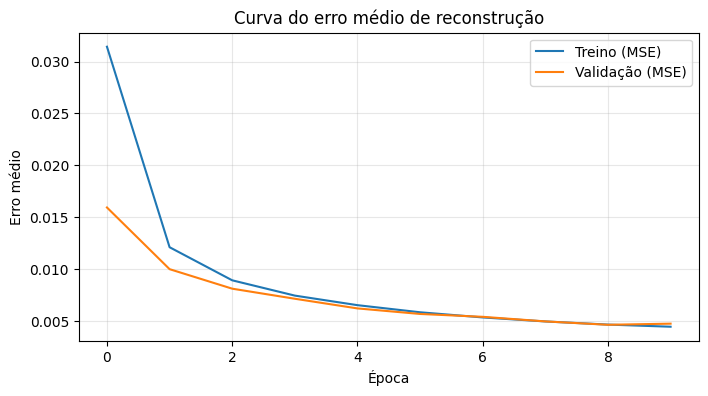

In [ ]:
# Curva do erro médio ao longo do treinamento
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Treino (MSE)")
plt.plot(history.history["val_loss"], label="Validação (MSE)")
plt.title("Curva do erro médio de reconstrução")
plt.xlabel("Época")
plt.ylabel("Erro médio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()